Competitive Market Analysis

Loads the bulk parquet into df, prints the company count, confirms the file is loaded

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

bulk  =  r"C:\MSC\Project\lloyds-commercial-banking-intelligence-2026\data\processed\dashboard_bulk_2026-07\dashboard_bulk_2026-07.parquet"
df = pd.read_parquet(bulk)
print(len(df), "companies loaded")

c:\conda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\conda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


1531094 companies loaded


In [3]:
GREEN, GREY, RED = "#006A4D", "#B9C4C0", "#C0392B"
plt.rcParams.update ({
    "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right":False,
    "axes.titlesize":12, "axes.titleweight":"bold",
    "font.size":10
})

#### The market at a glance
Before the lender detail, three plain views of July 2026 population: what sectors these companies are in, how big they are and how old. All from core Companies House fields, so they cover every company not just those with a loan.

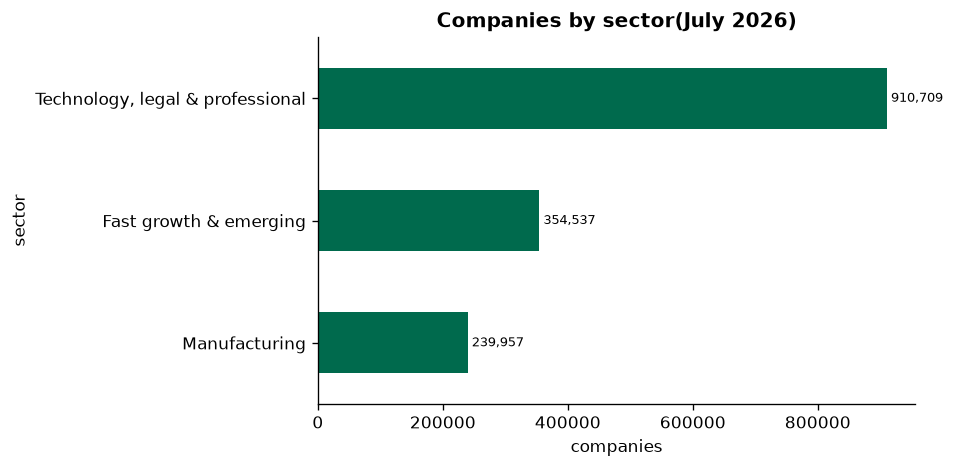

In [4]:
#sector breakdown
sector_counts =df["sector"].value_counts()
ax = sector_counts.plot(kind="barh", color=GREEN, figsize=(8,4))
ax.invert_yaxis()
ax.set_xlabel("companies");ax.set_title("Companies by sector(July 2026)")
for i, v, in enumerate(sector_counts):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
plt.tight_layout(); plt.show()        

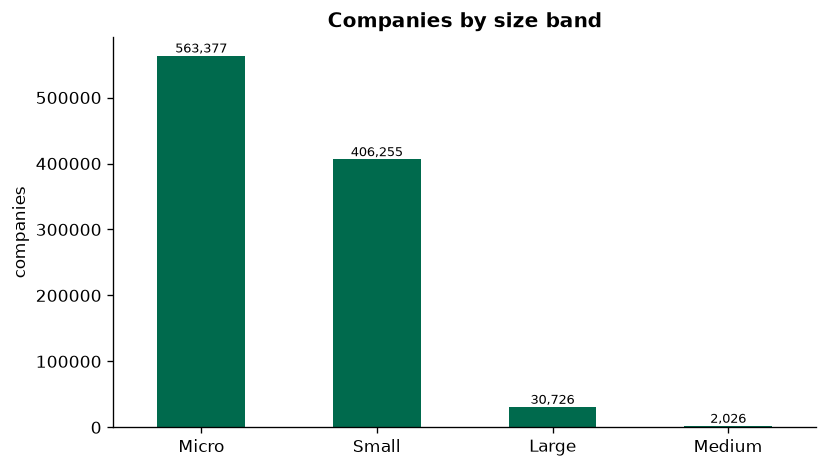

In [5]:
#size buckets
size_counts = df["size_tier"].value_counts()
ax = size_counts.plot(kind="bar", color=GREEN, figsize=(7,4))
ax.set_ylabel("companies"),
ax.set_xlabel(""),
ax.set_title("Companies by size band")
for x, v in enumerate(size_counts):
    ax.text(x,v,f"{v:,}", ha="center",va="bottom", fontsize=8)
plt.xticks(rotation =0)
plt.tight_layout(),
plt.show()

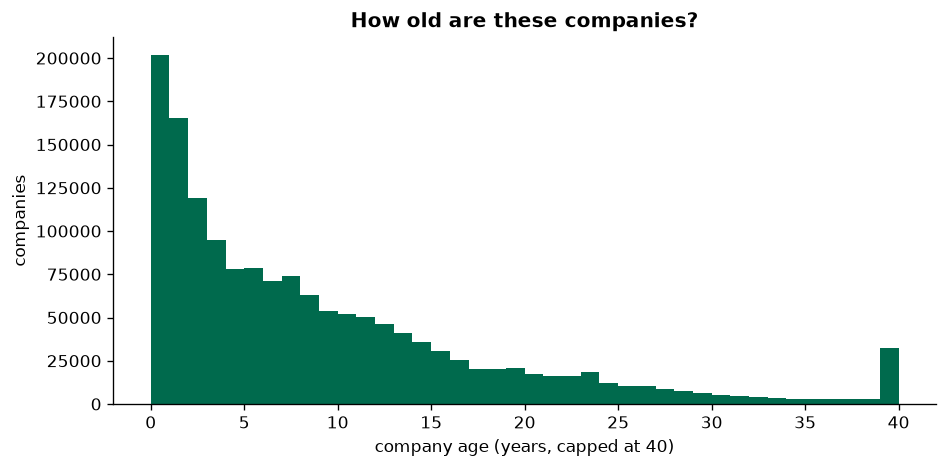

median age 6 years


In [6]:
# Company age distribution
age = df["company_age_years"].dropna()
plt.figure(figsize=(8,4))
plt.hist(age.clip(upper=40), bins=40, color=GREEN)
plt.xlabel("company age (years, capped at 40)");
plt.ylabel("companies")
plt.title("How old are these companies?")
plt.tight_layout();plt.show()
print(f"median age {age.median():.0f} years")

#### 1. Which banks lend to small businesses

Each company has a "main lender" - the bank holding most of its borrowing. Counting
companies by that gives a ranking of the banks. Lloyds is shown in green so it stands
out. The bigger the bar, the bigger that bank is in this market.

The league table - ranking of banks in SME secured lending, the order is roughly NatWest (~18.2k) › HSBC (~15.9k) › Barclays (~12k) › Lloyds (~10.6k), so it should print "Lloyds is number 4".

primary_lender_group
natwest                  18235
hsbc                     15899
barclays                 11974
lbg                      10604
challenger_bank           7512
asset_invoice_finance     6312
other_bank                5030
trustee_spv               4710
virgin_money              2224
santander                 1798
government                1470
insurer_pension            679
Name: count, dtype: int64


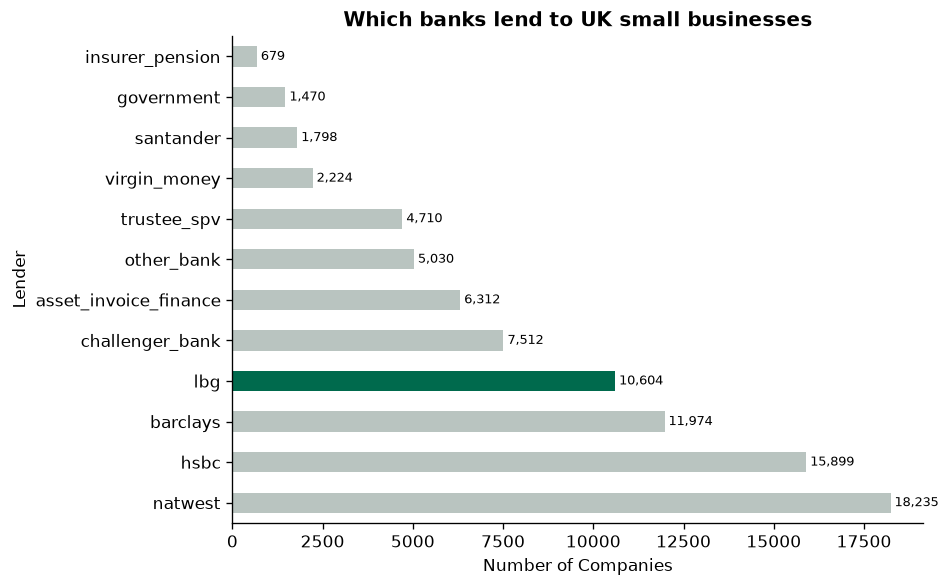

Lloyds is number 4 on the list


In [25]:
# count how many companies have each bank as their main lender
counts = df["primary_lender_group"].value_counts()
print(counts.head(12))

top = counts.head(12)

colors = [GREEN if lender == "lbg" else GREY for lender in top.index]

ax = top.plot(kind="barh", color=colors, figsize=(8, 5))
ax.invert_yaxis
ax.set_xlabel("Number of Companies")
ax.set_ylabel("Lender")
ax.set_title("Which banks lend to UK small businesses")
for i, v in enumerate(top):
    ax.text(v, i, f" {v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# where does Lloyds rank?
ranking = counts.index.tolist()
lloyds_rank = ranking.index("lbg") + 1
print("Lloyds is number", lloyds_rank, "on the list")

#### 2. Each bank's strength by sector

The same ranking, split across our three sectors. Each square shows what share of a
sector a bank holds.
Where each bank is strong per sector. A dark square shows a bank that holds an outsized share of one sector's borrowers, a competitor to watch in that sector.

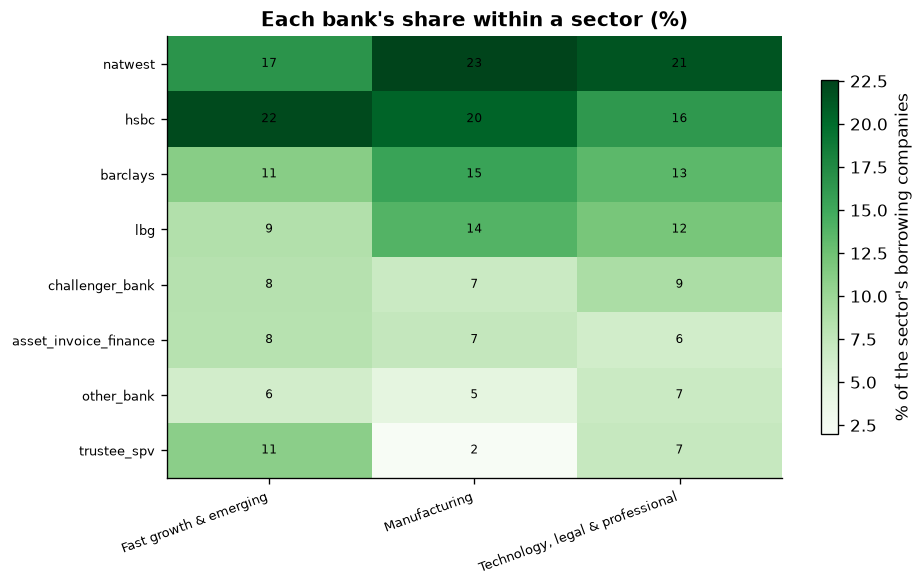

In [33]:
piv = pd.crosstab(df["primary_lender_group"], df["sector"])     
top8 =piv.sum(axis=1).sort_values(ascending=False).head(8).index
share_tbl = piv.loc[top8].div(piv.sum(axis=0), axis=1) * 100  

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(share_tbl.values, cmap="Greens", 
               aspect="auto")
ax.set_xticks(range(len(share_tbl.columns))); 
ax.set_xticklabels(share_tbl.columns, rotation=20, 
                   ha="right", fontsize=8)
ax.set_yticks(range(len(share_tbl.index)));   
ax.set_yticklabels(share_tbl.index, fontsize=8)
for i in range(len(share_tbl.index)):
    for j in range(len(share_tbl.columns)):
        ax.text(j, i, f"{share_tbl.values[i, j]:.0f}", 
                ha="center", va="center", fontsize=7)
ax.set_title("Each bank's share within a sector (%)")
fig.colorbar(im, ax=ax, shrink=0.8, label="% of the sector's borrowing companies")
plt.tight_layout()
plt.show()

#### 3. How concentrated is the market

Is lending spread across many banks or dominated by a few? We add up the share of the
biggest banks. If the top four hold about half, it is a concentrated market.

The HHI (Herfindahl-Hirschman Index) is a single score for how concentrated a market is, whether lending is spread across many banks or dominated by a few.

You take each bank's market share, square it, and add them all up:

- Squaring is the key step: it gives big banks far more weight than small ones, so a
  market ruled by one giant scores much higher than one split evenly among many.
- On this 0-to-1 scale: **near 0** means lots of small players and lots of competition;
  **1** means a single bank holds everything.
  
The curve climbs as we add banks largest-first - a steep early rise means a few banks own most of the market.Top-4 ~ half the market; HHI puts a single number on it (higher = more dominated by a few).

Top 4 banks hold 65.6% of the identified market.
Concentration index (HHI): 0.133


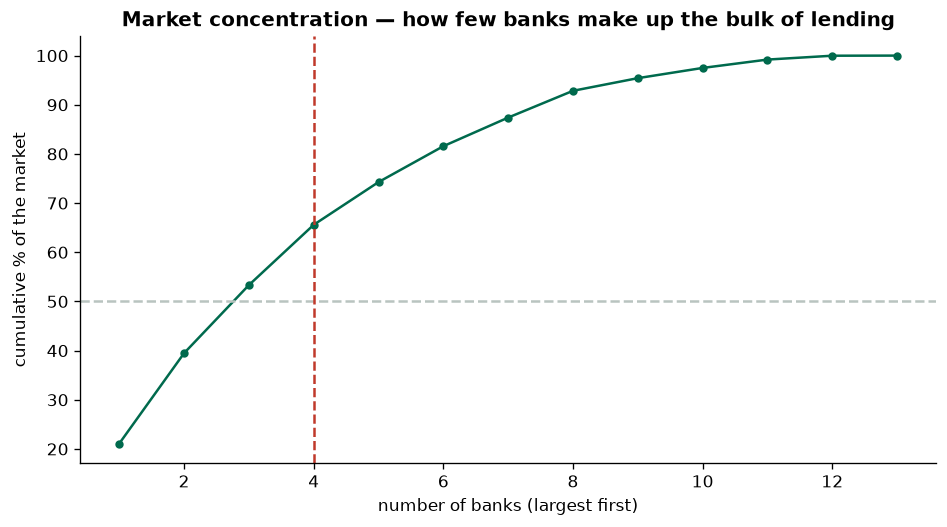

In [28]:
share = df["primary_lender_group"].value_counts(normalize=True) * 100
top4 = share.head(4).sum()
hhi  = ((share / 100) ** 2).sum()          # 0 = perfectly split, 1 = a monopoly
print(f"Top 4 banks hold {top4:.1f}% of the identified market.")
print(f"Concentration index (HHI): {hhi:.3f}")

cumulative = share.cumsum()
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cumulative) + 1), cumulative.values, "o-", color=GREEN, ms=4)
plt.axhline(50, color=GREY, ls="--")
plt.axvline(4, color=RED, ls="--")
plt.xlabel("number of banks (largest first)")
plt.ylabel("cumulative % of the market")
plt.title("Market concentration — how few banks make up the bulk of lending")
plt.tight_layout()
plt.show()

#### 4. How much of our clients' borrowing is ours

For each Lloyds client, what share of its borrowing sits with us. 100% means we are its only lender; less means a rival is already inside. A tall bar at 100% is good news.

11,733 current Lloyds clients | 73.3% borrow only from us


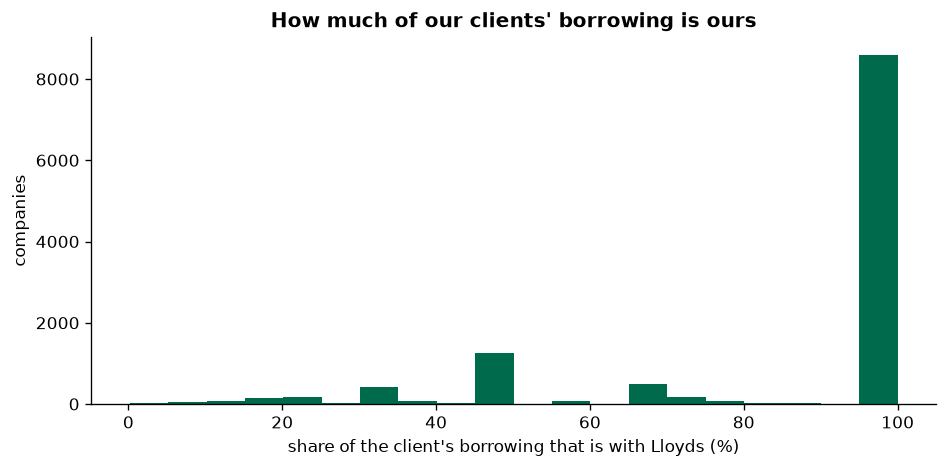

In [29]:
clients = df[df["is_lbg_client"] == True]
lbg_share = clients["lbg_share_of_outstanding"].dropna() * 100
sole = (lbg_share >= 99.9).mean() * 100
print(f"{len(clients):,} current Lloyds clients | {sole:.1f}% borrow only from us")

plt.figure(figsize=(8, 4))
plt.hist(lbg_share, bins=20, color=GREEN)
plt.xlabel("share of the client's borrowing that is with Lloyds (%)")
plt.ylabel("companies")
plt.title("How much of our clients' borrowing is ours")
plt.tight_layout()
plt.show()

#### 5. How contested is our book

For our clients, how many other banks are lending to them too. A large "0" bar means
most of our clients borrow only from us; the higher bars are the shared ones.

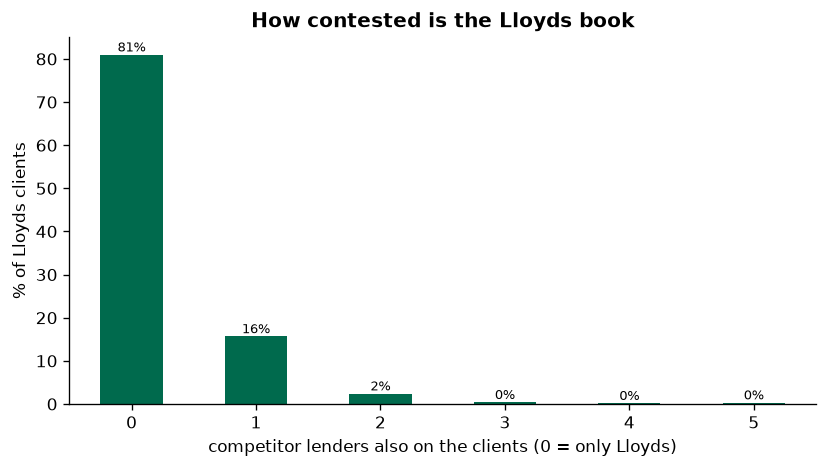

In [18]:
total_clients = len(clients)
rivals = clients["n_competitor_lenders"].clip(upper=5).value_counts().sort_index()
rivals_pct = rivals / total_clients * 100

ax = rivals_pct.plot(kind="bar", color=GREEN, figsize=(7,4))
ax.set_xlabel("competitor lenders also on the clients (0 = only Lloyds)")
ax.set_ylabel("% of Lloyds clients")
ax.set_title("How contested is the Lloyds book")
for x, v in enumerate(rivals_pct):
    ax.text(x, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=0);plt.tight_layout();plt.show()

#### 6. Clients under pressure

Three warning signs among our clients: they already share with a rival, a rival arrived in the last 12 months, or a rival gave them a new loan in the last 6 months. These are
the clients most at risk of leaving.

Total clients: 11733


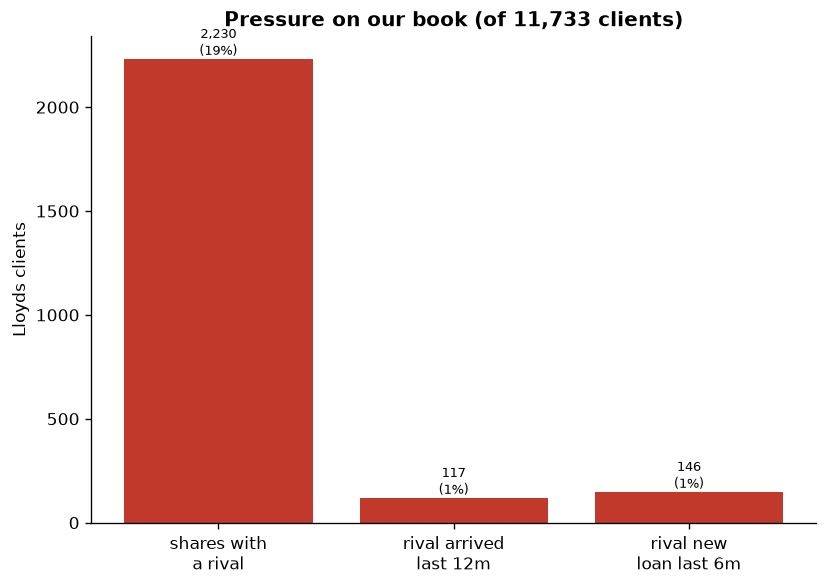

In [30]:
total      = len(clients)
with_rival = (clients["n_competitor_lenders"] > 0).sum()
rival_12m  = clients["competitor_entered_12m"].sum()
rival_6m   = clients["competitor_charge_created_6m"].sum()
print("Total clients:", total)

labels = ["shares with\na rival", "rival arrived\nlast 12m", "rival new\nloan last 6m"]
vals   = [with_rival, rival_12m, rival_6m]

plt.figure(figsize=(7, 5))
plt.bar(labels, vals, color=RED)
plt.ylabel("Lloyds clients")
plt.title(f"Pressure on our book (of {total:,} clients)")
for x, v in enumerate(vals):
    plt.text(x, v, f"{v:,}\n({v/total:.0%})", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

#### 7. Where our lapsed clients went

Companies that used to bank with Lloyds but don't now. Some have stopped borrowing; others now borrow from a rival - and for those we can see which one. 

14,416 lapsed Lloyds clients | 5,860 now borrow elsewhere | 8,556 have no live borrowing


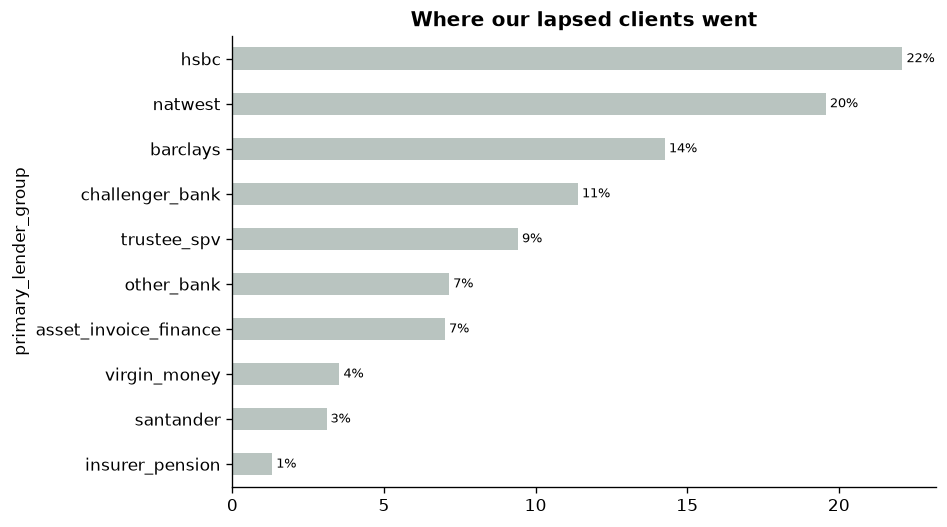

In [23]:
where = lapsed["primary_lender_group"]. value_counts().head(10)
where_pct =where/now_elsewhere * 100
print(f"{len(lapsed):,} lapsed Lloyds clients | {now_elsewhere:,} now borrow elsewhere | {no_borrow:,} have no live borrowing")


ax = where_pct[::-1].plot(kind="barh", color = GREY, figsize=(8,4.5))
ax.set_label("% of lapsed clients who now borrow elsewhere")
ax.set_title("Where our lapsed clients who now borrow elsewhere")
ax.set_title ("Where our lapsed clients went")
for i, v in enumerate(where_pct[::-1]):
    ax.text(v, i, f" {v:.0f}%", va="center", fontsize=8)
plt.tight_layout(); plt.show()

#### 8. Which sectors borrow, and where we stand

Per sector: how many companies there are, what share have a live loan at all, and what share of the sector banks with Lloyds. It shows where the borrowing - and the gap for us - is biggest.

                                  companies  have a loan %  \
sector                                                       
Technology, legal & professional     910709            5.5   
Fast growth & emerging               354537            3.4   
Manufacturing                        239957           15.7   

                                  borrow from Lloyds %  
sector                                                  
Technology, legal & professional                   0.6  
Fast growth & emerging                             0.2  
Manufacturing                                      2.2  


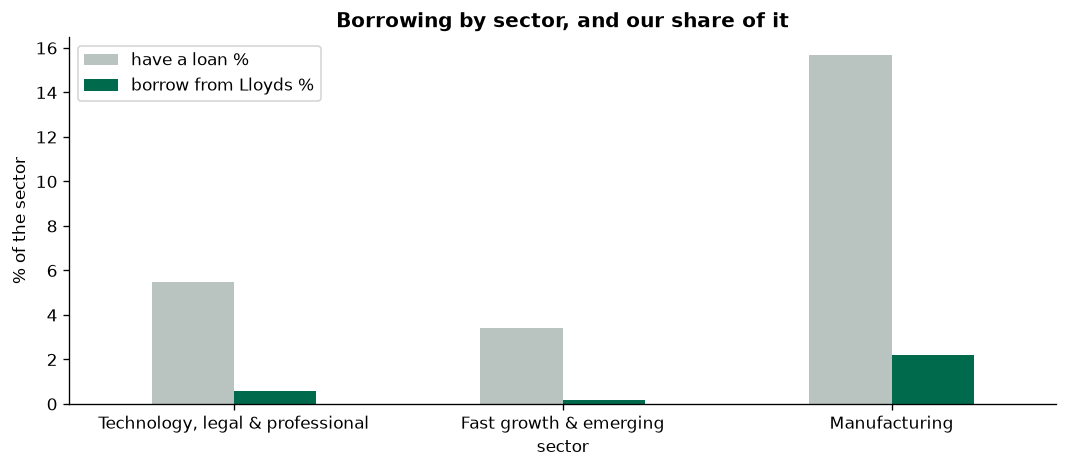

In [31]:
sectors = df[df["sector"].notna()].copy()
sectors["has_loan"] = sectors["Mortgages.NumMortOutstanding"] > 0

company_count = sectors.groupby("sector").size()
pct_loan      = sectors.groupby("sector")["has_loan"].mean() * 100
pct_lbg       = sectors.groupby("sector")["is_lbg_client"].mean() * 100

compare = pd.DataFrame({
    "companies":            company_count,
    "have a loan %":        pct_loan.round(1),
    "borrow from Lloyds %": pct_lbg.round(1),
}).sort_values("companies", ascending=False)
print(compare)

compare[["have a loan %", "borrow from Lloyds %"]].plot(kind="bar", figsize=(9, 4), color=[GREY, GREEN])
plt.ylabel("% of the sector")
plt.title("Borrowing by sector, and our share of it")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
counts.to_csv("mi_league_2026-07.csv")
where.to_csv("mi_lapsed_destinations_2026-07.csv")
compare.to_csv("mi_sector_borrowing_2026-07.csv")
print("saved 3 summary files")

saved 3 summary files


All of this is secured borrowing only, covering about 7% of companies, so it shows who
holds loans-against-assets, not overall banking share. Percentages leave out the 1-in-5
lenders we could not name. Sections 6 and 7 use summary flags, not dated events, so treat
the "who took our clients" view as a strong hint, not an exact count.